# What the campaign found

**Eleven language models. Six feedback conditions. 30 runs each. 19,222 trained agents.**

One section per idea: a figure, then what it shows.

*Status: rung 1 of 7. Campaign runs to 27 August.*

## 1. The question

> **Show a language model the *shape of the losses* instead of one performance number.
> Does it write different reward code, and does the trained agent end up safer?**

Everything downstream is frozen. Same learner, data, splits, budget. **Only the feedback block
changes.**

One detail matters more than any other: **candidate selection is tail-blind** (fitness is validation
Deflated Sharpe, no tail term). So a better tail cannot come from selection. **It can only come from
the code the model wrote.**

## 2. Vocabulary

**The six conditions**

| arm | what the model sees | rules out |
|---|---|---|
| **`distributional`** | six left-tail statistics | *the treatment* |
| **`scalar`** | one performance number | *the comparison* |
| `scalar_cvar5` | one number + **one** tail number | "any risk number would do" |
| `placebo` | one number + **same-length filler** | "more text helps" |
| `placebo_shuffled` | the six values **scrambled** | "structure, not content" |

**The questions**

| | |
|---|---|
| **H1** | Does the model beat 11 human-written objectives from the literature? |
| **H2-RA** | **R**isk-**A**djusted. Does tail feedback raise **Sharpe**? |
| **H2-Tail** | Does tail feedback give a **less severe left tail** (CVaR-5%)? |
| **H3** | Does iterating 30 candidates beat one shot? |
| **H4** | Does the model beat 4 optimisers at the same budget? |
| **SQ1 / SQ2 / SQ3** | Does the signal change the code / reach the outcome / is it genuine? |

**The measures**

| | |
|---|---|
| **Sharpe** | return ÷ volatility. Higher better. |
| **CVaR-5%** | average loss on the worst 5% of days. Closer to zero better. |
| **turnover** | share of portfolio traded per day. Expensive. |
| **gross vs net** | before and after trading costs. |

## One rule that decides the headline

**`distributional` had to beat all three of `scalar`, `placebo` and `scalar_cvar5`. Not one. All
three.** That rule was fixed before any data existed.

This is called an **intersection-union test (IUT)**, and the score is the **worst** of the three
comparisons, not the best.

**Why "all three" is the safeguard.** Normally, running three tests gives you three chances to get
lucky, so you must penalise the result to compensate. **Here it works the opposite way.** Requiring
every test to pass means a fluke would have to strike three times, in the same direction, on three
different comparisons. That is far harder than passing one.

> **So no extra penalty is needed. Requiring all three to agree IS the penalty.** That is what
> "the conjunction is the correction" means (Berger, 1982).

**And each comparison kills a specific objection:**

- beating **`scalar`** shows there is an effect at all
- beating **`placebo`** kills "it was just a longer prompt"
- beating **`scalar_cvar5`** kills "any risk number would have done it"

In [1]:
import sys, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = next(p for p in [HERE, *HERE.parents] if (p / "src" / "viz" / "style.py").exists())
for p in (str(REPO), str(REPO / "notebooks")):
    if p not in sys.path: sys.path.insert(0, p)
import prelim_loader as PL
from src.viz.style import OKABE_ITO, savefig

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 12,
                     "axes.titlesize": 14, "axes.labelsize": 12,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True, "legend.frameon": False})
FIG = REPO / "outputs" / "figures_presentation"; FIG.mkdir(parents=True, exist_ok=True)
rows, series = PL.load(REPO / "outputs" / "campaign_cluster_run4", REPO / "outputs" / "notebook_cache", verbose=False)
D = pd.DataFrame(rows); D["floor"] = D["seed"] < 30
BLUE, RED, GREY, GREEN, ORANGE = (OKABE_ITO["blue"], OKABE_ITO["vermillion"], OKABE_ITO["grey"],
                                  OKABE_ITO["green"], OKABE_ITO["orange"])
CONF = "opus_5"                       # the registered confirmatory line, one row among eleven

def nm(l): return "opus_5" if l == "test" else l.replace("test_leg_", "")
LINES = ["test"] + sorted(l for l in D.line.unique() if l.startswith("test_leg_"))
D["model"] = D.line.map(nm)
MODELS = [nm(l) for l in LINES]     # the 11 full-loop lines; excludes the single-arm H3 unit

def cell(l, a, m="sharpe"):
    q = D[(D.line == l) & (D.arm == a) & D.floor]
    return q.set_index("seed")[m].dropna().sort_index()
def paired(l, a, b, m="sharpe"):
    x, y = cell(l, a, m), cell(l, b, m)
    c = x.index.intersection(y.index); return (x.loc[c] - y.loc[c]).to_numpy(float)
def boot(x, reps=4000, al=0.10, seed=0):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if x.size < 2: return (float("nan"),) * 3
    r = np.random.default_rng(seed); m = x[r.integers(0, x.size, (reps, x.size))].mean(1)
    lo, hi = np.quantile(m, [al/2, 1-al/2]); return float(x.mean()), float(lo), float(hi)
def p_one(x, reps=20000, seed=0):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    o = x.mean(); r = np.random.default_rng(seed)
    return float((1 + int(((r.choice(np.array([-1.,1.]), (reps, x.size)) * x).mean(1) >= o).sum())) / (reps+1))

print("%d trained agents | %d models | %d arms" % (len(D), len(LINES), D.arm.nunique()))
print("confirmatory line (registered in advance): %s" % CONF)

19222 trained agents | 11 models | 20 arms
confirmatory line (registered in advance): opus_5


## 3. Every model, both halves of H2

Each row is one model. **Left: did the tail get safer? Right: did Sharpe rise?**

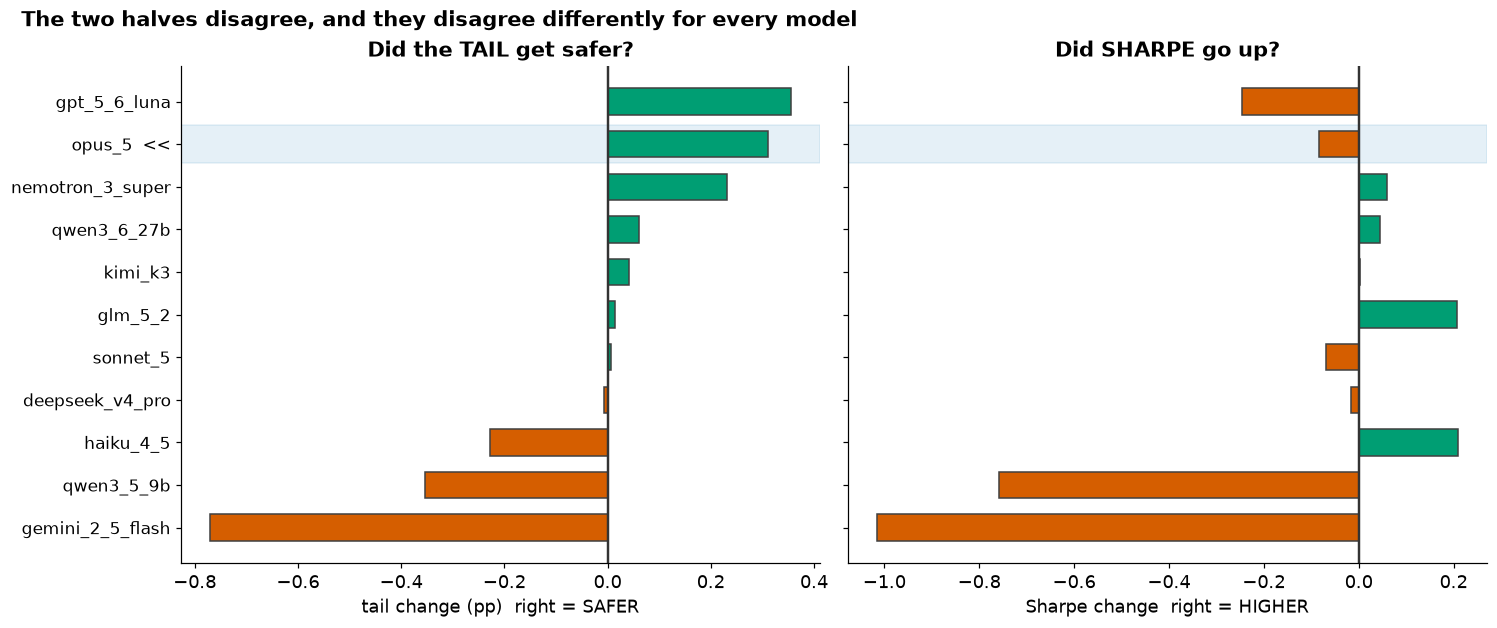

,tail effect,sharpe effect,H2-Tail (all 3 legs)
model,,,
gemini_2_5_flash,-0.7697,-1.0150,False
qwen3_5_9b,-0.3548,-0.7587,False
haiku_4_5,-0.2280,0.2088,False
deepseek_v4_pro,-0.0077,-0.0154,False
sonnet_5,0.0062,-0.0685,False
glm_5_2,0.0142,0.2074,False
kimi_k3,0.0421,0.0028,False
qwen3_6_27b,0.0609,0.0458,False
nemotron_3_super,0.2322,0.0601,False


In [2]:
COMPS = ("scalar", "placebo", "scalar_cvar5")
R = []
for l in LINES:
    ps = [p_one(paired(l, "distributional", c, "oos_cvar_05")) for c in COMPS]
    R.append({"model": nm(l),
              "tail effect": paired(l, "distributional", "scalar", "oos_cvar_05").mean() * 100,
              "sharpe effect": paired(l, "distributional", "scalar", "sharpe").mean(),
              "H2-Tail (all 3 legs)": max(ps) < 0.05})
R = pd.DataFrame(R).sort_values("tail effect")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), sharey=True)
y = np.arange(len(R))
for ax, col, lab, good_right in ((axes[0], "tail effect", "tail change (pp)  right = SAFER", True),
                                 (axes[1], "sharpe effect", "Sharpe change  right = HIGHER", True)):
    cols = [GREEN if v > 0 else RED for v in R[col]]
    ax.barh(y, R[col], color=cols, edgecolor="0.25", height=0.62)
    ax.axvline(0, color="0.2", lw=1.6)
    ax.set_xlabel(lab)
for i, m in enumerate(R.model):
    if m == CONF:
        for ax in axes:
            ax.axhspan(i-0.45, i+0.45, color=BLUE, alpha=0.10, zorder=0)
axes[0].set_yticks(y)
axes[0].set_yticklabels([("%s  <<" % m) if m == CONF else m for m in R.model], fontsize=11)
axes[0].set_title("Did the TAIL get safer?", fontweight="bold")
axes[1].set_title("Did SHARPE go up?", fontweight="bold")
fig.suptitle("The two halves disagree, and they disagree differently for every model",
             x=0.01, ha="left", fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "P1_two_halves.png"); plt.show()
display(R.set_index("model").round(4))

**Three things to see.**

- **The two columns are not the same ranking.** A model can get a safer tail and a lower Sharpe, or
  the reverse. That is why the study registered two separate tests.
- **The signs are mixed.** Tail feedback helps some models and harms others. **There is no single
  effect to report.**
- **`opus_5` (highlighted) is the registered confirmatory line**, chosen before any data. It is the
  only model that passes the full three-comparator test, and it is one row among eleven.

## 4. Why the models differ: they trade differently

Tail feedback changes **how much the agent trades**. Trading is expensive.

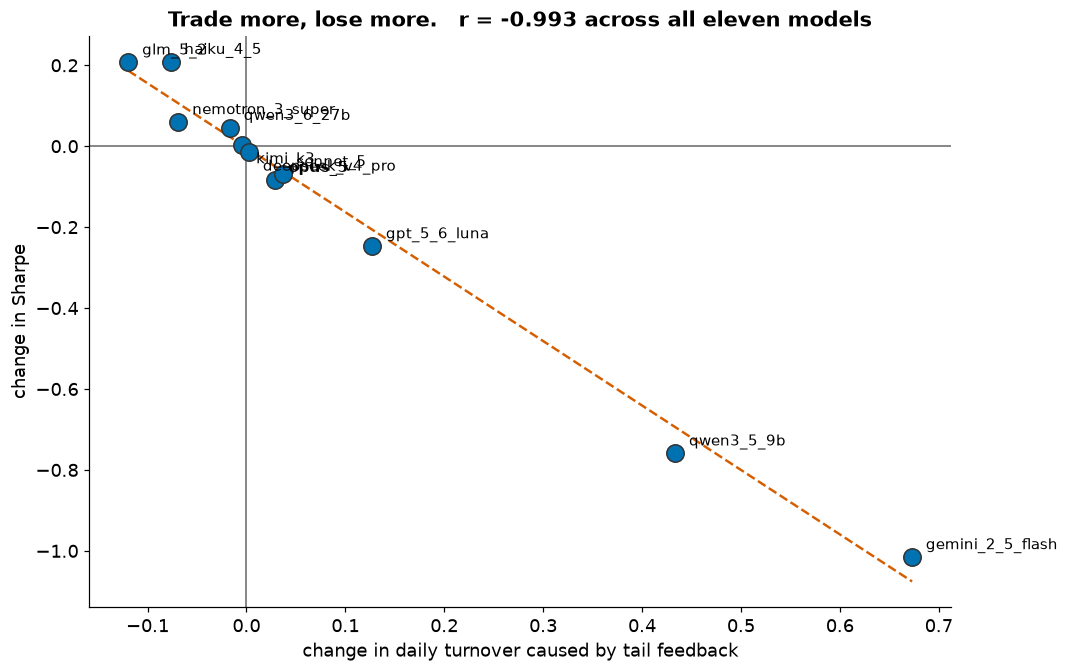

,turn_scalar,turn_distributional,turnover change,gross change,net change
model,,,,,
glm_5_2,0.405,0.286,-0.119,0.014,0.207
haiku_4_5,0.084,0.008,-0.077,0.053,0.209
nemotron_3_super,0.372,0.303,-0.069,-0.001,0.060
qwen3_6_27b,0.049,0.033,-0.017,0.012,0.046
kimi_k3,0.013,0.009,-0.004,-0.005,0.003
deepseek_v4_pro,0.008,0.010,0.003,-0.011,-0.015
opus_5,0.028,0.057,0.029,-0.013,-0.083
sonnet_5,0.011,0.047,0.037,-0.001,-0.069
gpt_5_6_luna,0.014,0.141,0.127,-0.012,-0.247


turnover change vs NET Sharpe change   : r = -0.993
turnover change vs GROSS Sharpe change : r = -0.975


In [3]:
g = (D[D.floor & D.arm.isin(["distributional", "scalar"]) & D.model.isin(MODELS)]
     .groupby(["model", "arm"]).agg(net=("sharpe", "mean"), gross=("sharpe_gross", "mean"),
                                    turn=("turnover_mean", "mean")).unstack())
g.columns = ["_".join(c) for c in g.columns]
g["turnover change"] = g.turn_distributional - g.turn_scalar
g["net change"] = g.net_distributional - g.net_scalar
g["gross change"] = g.gross_distributional - g.gross_scalar
g = g.sort_values("turnover change")
r = g[["turnover change", "net change"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9.6, 6.0))
ax.scatter(g["turnover change"], g["net change"], s=130, color=BLUE, edgecolor="0.2", zorder=3)
for m_, row in g.iterrows():
    off = (9, 5) if abs(row["net change"]) > 0.04 else (9, -12)
    ax.annotate(m_, (row["turnover change"], row["net change"]), fontsize=10,
                xytext=off, textcoords="offset points",
                fontweight="bold" if m_ == CONF else "normal")
z = np.polyfit(g["turnover change"], g["net change"], 1)
xs = np.linspace(g["turnover change"].min(), g["turnover change"].max(), 20)
ax.plot(xs, np.polyval(z, xs), color=RED, lw=1.6, ls="--", zorder=2)
ax.axhline(0, color="0.4", lw=1); ax.axvline(0, color="0.4", lw=1)
ax.set_xlabel("change in daily turnover caused by tail feedback")
ax.set_ylabel("change in Sharpe")
ax.set_title("Trade more, lose more.   r = %+0.3f across all eleven models" % r, fontweight="bold")
savefig(fig, FIG / "P2_turnover.png"); plt.show()
display(g[["turn_scalar", "turn_distributional", "turnover change", "gross change", "net change"]].round(3))
print("turnover change vs NET Sharpe change   : r = %+0.3f" % r)
print("turnover change vs GROSS Sharpe change : r = %+0.3f"
      % g[["turnover change", "gross change"]].corr().iloc[0, 1])

**This one variable explains almost the whole picture.**

- **r = −0.993.** Knowing only whether tail feedback made a model trade more or less nearly tells you
  whether it gained or lost.
- **Gross Sharpe barely moves.** The strategies pick similarly good positions. **The damage is
  entirely trading cost.**
- The two collapses, `gemini_2_5_flash` (0.22 → 0.89 turnover) and `qwen3_5_9b` (0.40 → 0.83), stay
  profitable *before* costs and go negative after.
- `opus_5` moved only 0.028 → 0.057. **Small cost, real tail gain.** That is why it is the one model
  that passes.

⚠ Correlation across eleven points, not a manipulation. Repricing the grid at other cost levels needs
no retraining and would settle it. Not yet run.

## 5. What actually drives the outcome

Three things could matter: which model, which feedback, or luck.

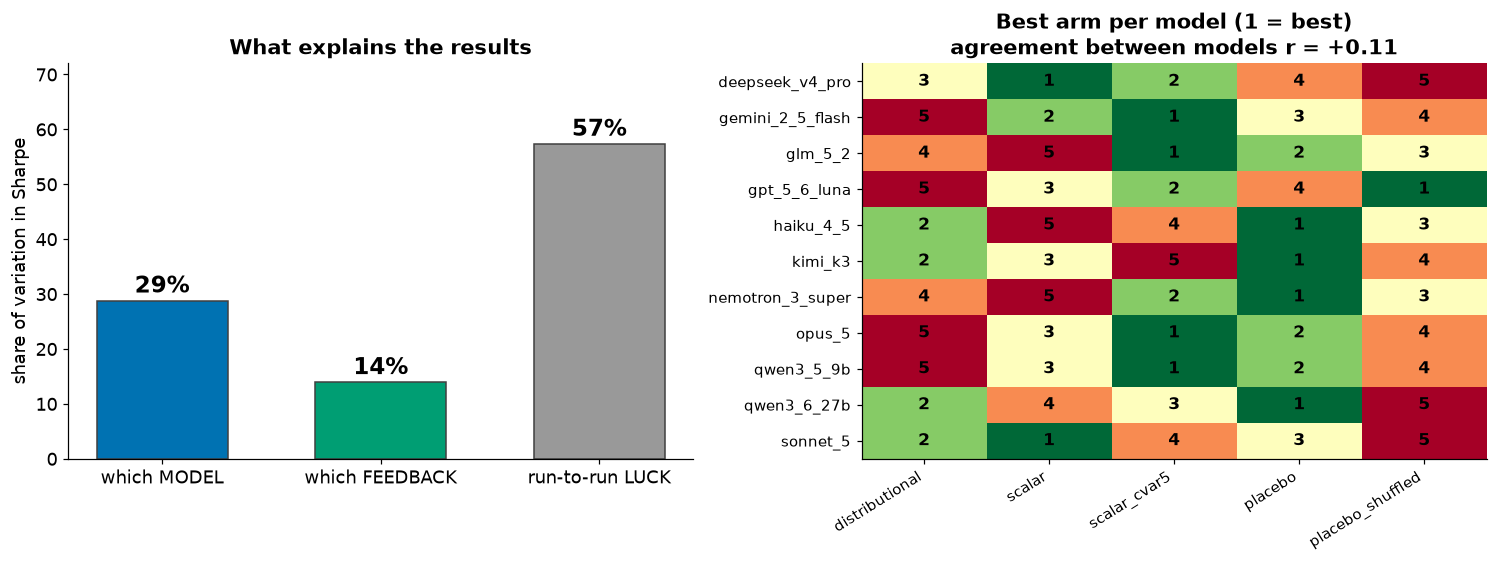

model 28.8% | feedback arm 13.9% | seed and interactions 57.3%


In [4]:
A = D[D.floor & D.model.isin(MODELS)
      & D.arm.isin(["distributional","scalar","scalar_cvar5","placebo","placebo_shuffled"])]
tot = A.sharpe.var()
gm, ga = A.groupby("model").sharpe.mean(), A.groupby("arm").sharpe.mean()
v_m, v_a = A.model.map(gm).var(), A.arm.map(ga).var()
v_r = (A.sharpe - A.model.map(gm) - A.arm.map(ga) + A.sharpe.mean()).var()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
ax = axes[0]
parts = [("which MODEL", 100*v_m/tot, BLUE), ("which FEEDBACK", 100*v_a/tot, GREEN),
         ("run-to-run LUCK", 100*v_r/tot, GREY)]
ax.bar([p[0] for p in parts], [p[1] for p in parts], color=[p[2] for p in parts],
       edgecolor="0.25", width=0.6)
for i, p in enumerate(parts):
    ax.text(i, p[1]+1.5, "%.0f%%" % p[1], ha="center", fontsize=15, fontweight="bold")
ax.set_ylabel("share of variation in Sharpe"); ax.set_ylim(0, 72)
ax.set_title("What explains the results", fontweight="bold")

ax = axes[1]
piv = A.groupby(["model","arm"]).sharpe.mean().unstack()[
      ["distributional","scalar","scalar_cvar5","placebo","placebo_shuffled"]]
rk = piv.rank(axis=1, ascending=False)
im = ax.imshow(rk.values, cmap="RdYlGn_r", vmin=1, vmax=5, aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(piv.columns, rotation=32, ha="right", fontsize=10)
ax.set_yticks(range(len(rk))); ax.set_yticklabels(rk.index, fontsize=10)
for i in range(rk.shape[0]):
    for j in range(rk.shape[1]):
        ax.text(j, i, int(rk.values[i,j]), ha="center", va="center", fontsize=11, fontweight="bold")
from itertools import combinations
cors = [np.corrcoef(rk.loc[a], rk.loc[b])[0,1] for a,b in combinations(rk.index,2)]
ax.set_title("Best arm per model (1 = best)\nagreement between models r = %+0.2f" % np.mean(cors),
             fontweight="bold")
ax.grid(False)
savefig(fig, FIG / "P3_what_drives.png"); plt.show()
print("model %.1f%% | feedback arm %.1f%% | seed and interactions %.1f%%"
      % (100*v_m/tot, 100*v_a/tot, 100*v_r/tot))

- **Which model you use matters about twice as much as what you show it** (29% against 14%).
- **Run-to-run luck dwarfs both** (57%). This is the argument for 30 seeds per arm, and against any
  paper reporting a handful of runs.
- **The models do not agree on which feedback is best** (agreement r = +0.11). `distributional` ranks
  near the top for `haiku_4_5`, `kimi_k3`, `qwen3_6_27b`, and last for four others.

> **There is no universally best feedback design. It depends on the model.** Most papers in this area
> demonstrate a technique on one model and present it as a property of the technique.

## 6. The failure mechanism: some models wrote code that crashes

Reward code runs inside the training loop. When it raises, a default is substituted and counted.

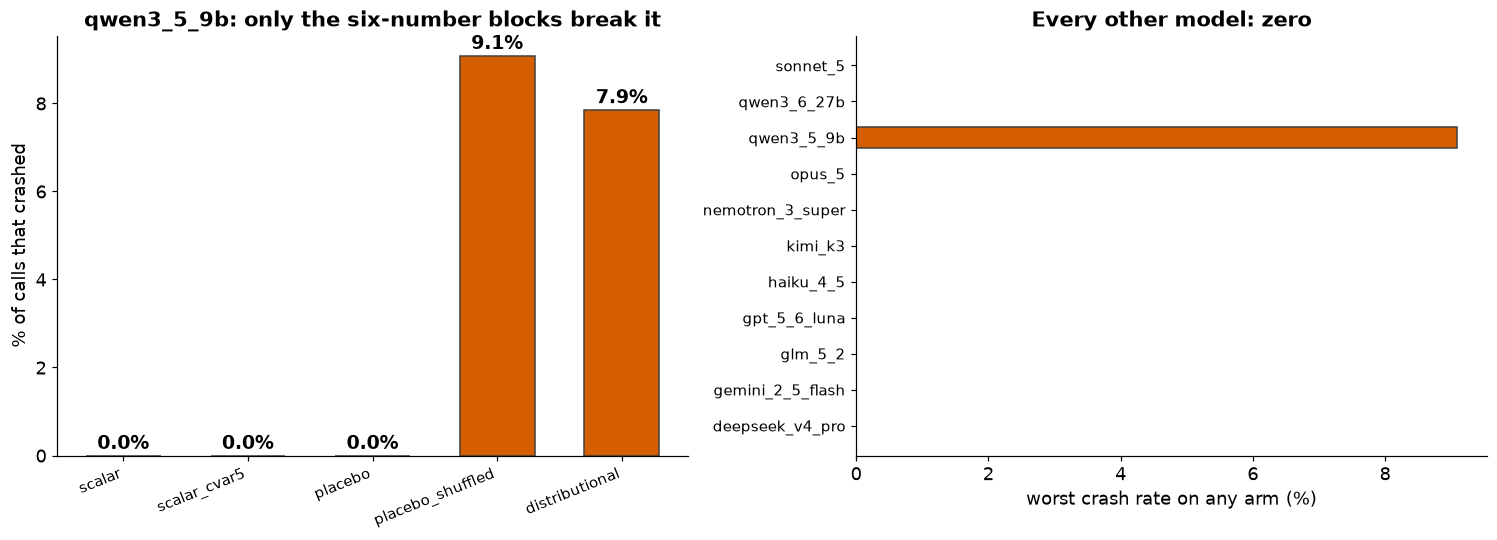

cells with any crash: 4 of 70
   qwen3_5_9b           placebo_shuffled       9.08%
   qwen3_5_9b           distributional         7.85%
   opus_5               baseline_differential_downside_ratio   0.00%
   opus_5               baseline_differential_sharpe   0.00%


In [5]:
byc = D[D.floor & D.model.isin(MODELS)].groupby(["model","arm"]).safe_default_rate.mean()
nz = byc[byc > 1e-9].sort_values(ascending=False)
worst = nz.index[0][0]
arms = ["scalar","scalar_cvar5","placebo","placebo_shuffled","distributional"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
vals = [100*byc.get((worst,a),0.0) for a in arms]
b = ax.bar(np.arange(len(arms)), vals, color=[GREY,GREY,GREY,RED,RED], edgecolor="0.25", width=0.6)
for bb,v in zip(b, vals): ax.text(bb.get_x()+bb.get_width()/2, v+0.15, "%.1f%%" % v,
                                  ha="center", fontsize=12.5, fontweight="bold")
ax.set_xticks(np.arange(len(arms))); ax.set_xticklabels(arms, rotation=22, ha="right", fontsize=10)
ax.set_ylabel("% of calls that crashed")
ax.set_title("%s: only the six-number blocks break it" % worst, fontweight="bold")

ax = axes[1]
allm = byc.groupby("model").max().reindex(sorted(MODELS)) * 100
ax.barh(np.arange(len(allm)), allm.values, color=[RED if v>0.01 else GREY for v in allm.values],
        edgecolor="0.25", height=0.6)
ax.set_yticks(np.arange(len(allm))); ax.set_yticklabels(allm.index, fontsize=10)
ax.set_xlabel("worst crash rate on any arm (%)")
ax.set_title("Every other model: zero", fontweight="bold")
savefig(fig, FIG / "P4_crashes.png"); plt.show()
print("cells with any crash: %d of %d" % (len(nz), byc.size))
for (m,a),v in nz.head(4).items(): print("   %-20s %-20s %6.2f%%" % (m, a, 100*v))

- **`qwen3_5_9b` is the only model whose code fails.** Shown one number: 0%. Shown the six-number
  block: **7.9%**. Scrambled block: 9.1%.
- Those are exactly its two failing arms. It trained against a reward that was silently defaulting
  one call in thirteen.
- **Every other model: zero.** So this is a capability limit, not a flaw in the feedback design.

⚠ **It does not explain `gemini_2_5_flash`**, which never crashes and still collapses. That one is
explained by turnover (Section 4). **Two failures, one shared mechanism, one with an extra problem.**

## 7. Model size: two families, two different stories

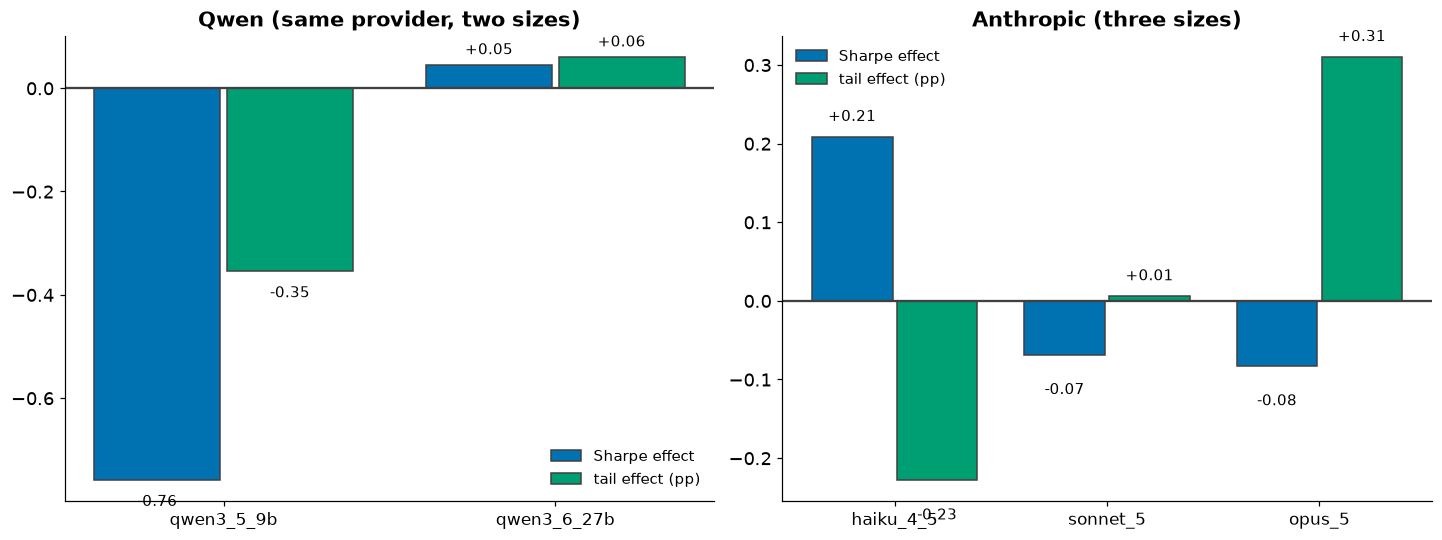

In [6]:
fams = {"Qwen (same provider, two sizes)": ["qwen3_5_9b","qwen3_6_27b"],
        "Anthropic (three sizes)": ["haiku_4_5","sonnet_5","opus_5"]}
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for ax,(fam,ms) in zip(axes, fams.items()):
    ms = [m for m in ms if m in piv.index]
    sh = [piv.loc[m,"distributional"]-piv.loc[m,"scalar"] for m in ms]
    cv = [paired("test" if m=="opus_5" else "test_leg_"+m,"distributional","scalar","oos_cvar_05").mean()*100
          for m in ms]
    x = np.arange(len(ms))
    ax.bar(x-0.2, sh, width=0.38, color=BLUE, edgecolor="0.25", label="Sharpe effect")
    ax.bar(x+0.2, cv, width=0.38, color=GREEN, edgecolor="0.25", label="tail effect (pp)")
    ax.axhline(0, color="0.25", lw=1.5)
    ax.set_xticks(x); ax.set_xticklabels(ms, fontsize=11)
    ax.set_title(fam, fontweight="bold"); ax.legend(fontsize=10)
    for i,(a_,b_) in enumerate(zip(sh,cv)):
        ax.text(i-0.2, a_+(0.02 if a_>=0 else -0.05), "%+.2f" % a_, ha="center", fontsize=10)
        ax.text(i+0.2, b_+(0.02 if b_>=0 else -0.05), "%+.2f" % b_, ha="center", fontsize=10)
savefig(fig, FIG / "P5_size.png"); plt.show()

- **Qwen is clean.** Same provider, same setup, different size. The 9B is badly harmed. The 27B is not.
- ⚠ **Anthropic is not.** The *smallest*, `haiku_4_5`, has the **best Sharpe effect** (+0.21). A simple
  "bigger is better" story is refuted by our own data.
- **The resolution:** on the **tail**, `haiku_4_5` gets *worse* (−0.23pp) while `opus_5` gets *better*
  (+0.31pp). Haiku gained Sharpe by trading less, not by managing risk.

> **Capability predicts whether a model can use tail information to improve the tail. It does not
> predict Sharpe, because Sharpe is dominated by turnover.**

Raise this yourself. If an examiner spots the non-monotonic ladder first, the capability story looks
invented after the fact.

## 8. H1: against eleven human-written objectives

Objectives taken from published finance papers, implemented as specified.

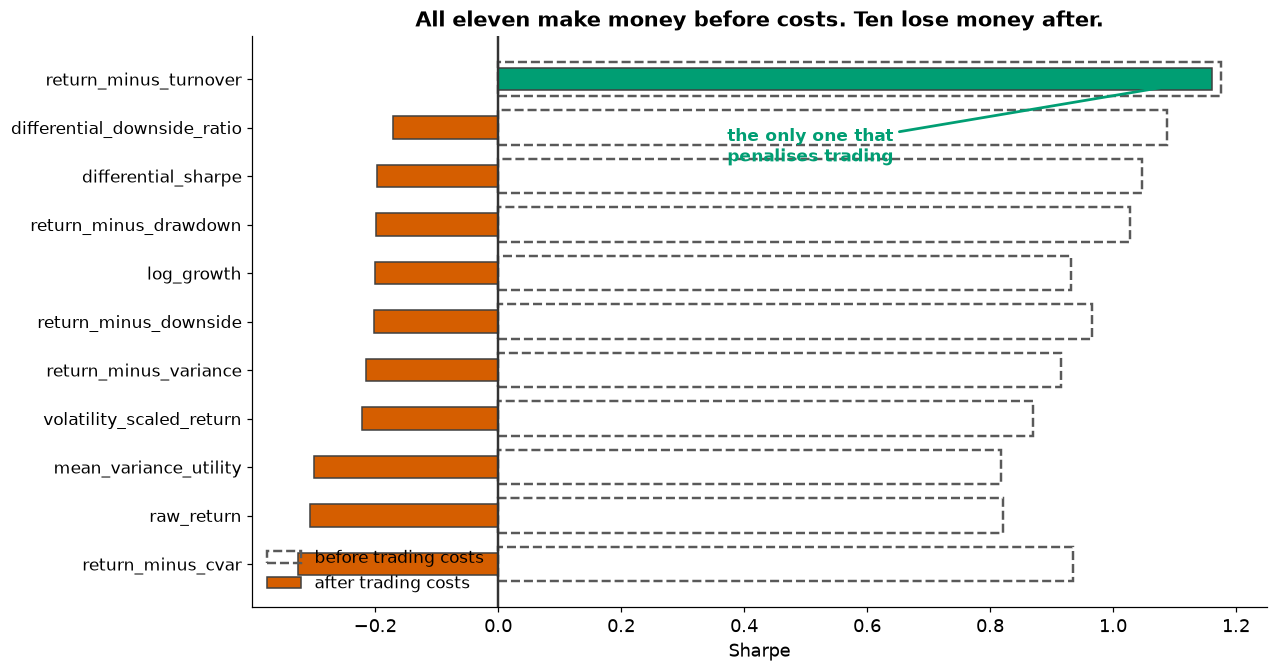

turnover: survivor 0.0077/day, median of the other ten 0.8885/day
every LLM arm scored between +1.05 and +1.16


In [7]:
o = D[(D.line=="test") & D.floor]
canon = o[o.arm.str.startswith("baseline_")].groupby("arm").agg(
    net=("sharpe","mean"), gross=("sharpe_gross","mean"), turn=("turnover_mean","mean")).sort_values("net")
canon.index = [i.replace("baseline_","") for i in canon.index]
fig, ax = plt.subplots(figsize=(11.5, 6.0))
y = np.arange(len(canon))
ax.barh(y, canon.gross, height=0.72, facecolor="none", edgecolor="0.35", lw=1.6, ls="--",
        label="before trading costs")
ax.barh(y, canon.net, height=0.46, color=[GREEN if v>0 else RED for v in canon.net],
        edgecolor="0.25", label="after trading costs")
ax.axvline(0, color="0.2", lw=1.6)
ax.set_yticks(y); ax.set_yticklabels(canon.index, fontsize=11)
ax.set_xlabel("Sharpe")
ax.set_title("All eleven make money before costs. Ten lose money after.", fontweight="bold")
ax.legend(loc="lower left", fontsize=11)
ax.annotate("the only one that\npenalises trading", xy=(canon.net.iloc[-1], len(canon)-1),
            xytext=(0.55,0.78), textcoords="axes fraction", fontsize=11, color=GREEN,
            fontweight="bold", ha="center", arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.8))
savefig(fig, FIG / "P6_humans.png"); plt.show()
print("turnover: survivor %.4f/day, median of the other ten %.4f/day"
      % (canon.turn.min(), canon.turn.drop(canon.turn.idxmin()).median()))
llm = o[o.arm.isin(["distributional","scalar","scalar_cvar5","placebo","placebo_shuffled"])]
print("every LLM arm scored between %+0.2f and %+0.2f"
      % (llm.groupby("arm").sharpe.mean().min(), llm.groupby("arm").sharpe.mean().max()))

- **All eleven are profitable before costs. Ten lose money after.** They trade ~89% of the portfolio
  daily and give the whole gross return to fees.
- **The survivor is the only one with a turnover penalty**, trades 0.8% a day, and is the best arm in
  the study.
- Every automated designer found the cost constraint without being told.

> **The claim is not "AI beats humans". It is: ten of eleven published objectives do not price
> transaction costs, and every automated designer discovered it must.**

⚠ The baselines are un-tuned and evaluated once. The automated arms are winners of a 30-candidate
search. **Section 9 prices that.**

## 9. H4: against optimisers with no language model

Four search methods, identical 30-candidate budget, same reward space.

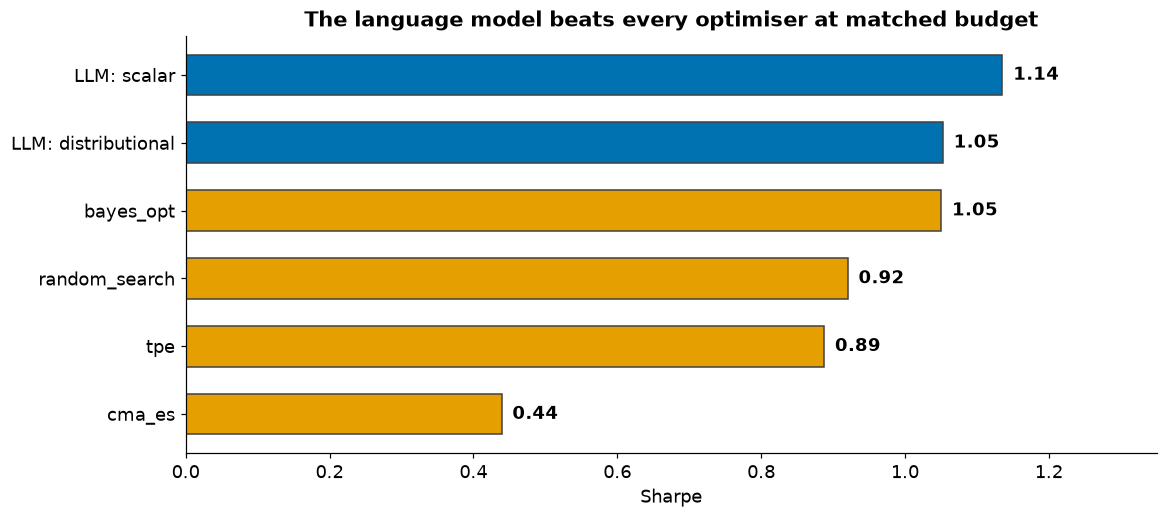

   scalar           vs random_search   +0.215  LLM better
   scalar           vs bayes_opt       +0.085  LLM better
   scalar           vs cma_es          +0.696  LLM better
   scalar           vs tpe             +0.248  LLM better
   distributional   vs random_search   +0.132  LLM better
   distributional   vs bayes_opt       +0.002  tie
   distributional   vs cma_es          +0.614  LLM better
   distributional   vs tpe             +0.165  LLM better


In [8]:
dfo = ["random_search","bayes_opt","cma_es","tpe"]
vals = {a: cell("test", a).mean() for a in dfo}
vals["LLM: scalar"] = cell("test","scalar").mean()
vals["LLM: distributional"] = cell("test","distributional").mean()
srt = sorted(vals.items(), key=lambda kv: kv[1])
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.barh(np.arange(len(srt)), [v for _,v in srt],
        color=[BLUE if k.startswith("LLM") else ORANGE for k,_ in srt], edgecolor="0.25", height=0.6)
for i,(k,v) in enumerate(srt): ax.text(v+0.015, i, "%.2f" % v, va="center", fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(len(srt))); ax.set_yticklabels([k for k,_ in srt], fontsize=11.5)
ax.set_xlabel("Sharpe"); ax.set_xlim(0, 1.35)
ax.set_title("The language model beats every optimiser at matched budget", fontweight="bold")
savefig(fig, FIG / "P7_optimisers.png"); plt.show()
for arm in ("scalar","distributional"):
    for comp in dfo:
        m, lo, hi = boot(paired("test", arm, comp, "sharpe"))
        print("   %-16s vs %-14s %+7.3f  %s" % (arm, comp, m,
              "LLM better" if lo>0 else ("LLM worse" if hi<0 else "tie")))

- **Both LLM arms beat all four optimisers.** They had the same budget on the same problem.
- **This answers the H1 objection.** The gap is not from having 30 attempts. It is from what the model
  does with them.
- ⚠ `distributional` only **ties** `bayes_opt`, because it deliberately gave up Sharpe. And `cma_es`
  is unusually weak. **`bayes_opt` is the real benchmark, not four easy wins.**

## 10. H3: does iterating help?

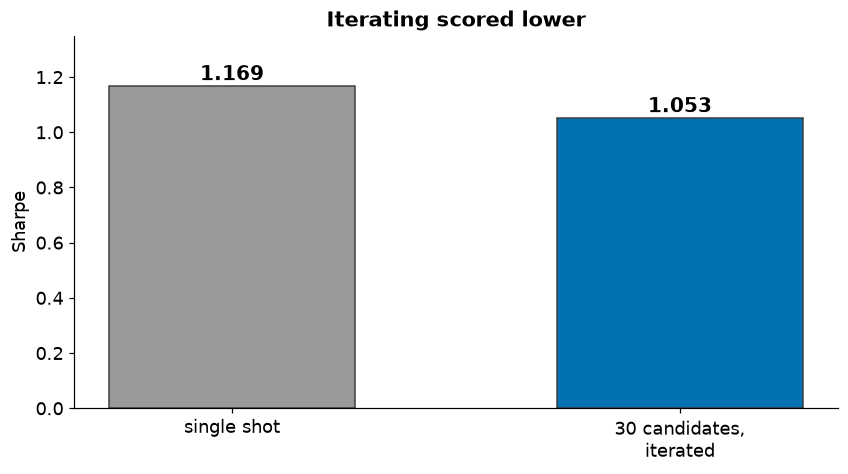

difference -0.116  [-0.164, -0.068], 30 paired runs


In [9]:
a, b = cell("test","distributional"), cell("test_h3_singleshot","distributional")
c = a.index.intersection(b.index)
m, lo, hi = boot((a.loc[c]-b.loc[c]).to_numpy(float))
fig, ax = plt.subplots(figsize=(7.6, 4.2))
bars = ax.bar(["single shot","30 candidates,\niterated"], [b.loc[c].mean(), a.loc[c].mean()],
              color=[GREY, BLUE], width=0.55, edgecolor="0.25")
for bb,v in zip(bars,[b.loc[c].mean(), a.loc[c].mean()]):
    ax.text(bb.get_x()+bb.get_width()/2, v+0.02, "%.3f" % v, ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("Sharpe"); ax.set_ylim(0,1.35)
ax.set_title("Iterating scored lower", fontweight="bold")
savefig(fig, FIG / "P8_iteration.png"); plt.show()
print("difference %+0.3f  [%+0.3f, %+0.3f], %d paired runs" % (m, lo, hi, len(c)))

- **The single shot scored higher**, by 0.116.
- **The likely reason:** the iterated arm is the tail-fed arm. More rounds of tail feedback means more
  of the safety-for-return trade. **Iteration worked. Sharpe is the wrong axis to see it on.**

⚠ **Confounded by design.** The single-shot unit also runs `distributional`, so this compares one
round of tail feedback against thirty, not iteration against no iteration. **Present as an open
question with a leading hypothesis**, not a settled result.

## 11. How much can we trust 30 runs?

In [10]:
dec = []
for l in LINES:
    d = paired(l, "distributional", "scalar", "sharpe")   # seed-matched, not position-matched
    if d.size < 5: continue
    dec.append({"model": nm(l), "spread between runs": d.std(ddof=1),
                "runs needed for a firm verdict": int(np.ceil((2*1.645*d.std(ddof=1)/0.05)**2))})
DEC = pd.DataFrame(dec).sort_values("spread between runs")
display(DEC.set_index("model").round(3))
print("Opus effect on Sharpe is -0.083 against a run-to-run spread of %.3f"
      % DEC.set_index("model").loc[CONF,"spread between runs"])

,spread between runs,runs needed for a firm verdict
model,,
deepseek_v4_pro,0.090,36
haiku_4_5,0.124,67
sonnet_5,0.137,82
kimi_k3,0.149,97
opus_5,0.161,112
gpt_5_6_luna,0.208,188
qwen3_6_27b,0.216,203
qwen3_5_9b,0.291,367
gemini_2_5_flash,0.340,502


Opus effect on Sharpe is -0.083 against a run-to-run spread of 0.161


- **Run-to-run spread is 0.09 to 0.58 Sharpe units.** Many of the effects here are smaller than that.
  **Hence pairing, and hence 30 runs minimum.**
- **Detecting a difference is easier than proving there is none.** Bounding Opus's Sharpe difference
  inside the registered margin needs **~112 runs**. We have 30.
- ⚠ **A pre-launch estimate did not reproduce.** The pilot predicted a spread of 0.369 and a
  *negative* pairing benefit. The campaign measures ~0.21 and a *positive* one. **The pilot was
  pessimistic on a small sample.**

## 12. Why the design carries the result

- **The prediction predates the data.** Three outcomes were registered and one predicted. That one
  occurred. The file is hash-sealed.
- **The test is hostile by design.** Beat all three comparators, and the score is the worst leg.
- **Stopping date fixed in advance** (27 August). Optional stopping is impossible.
- **Selection is tail-blind**, so a tail gain cannot be a selection artefact.
- **Eleven models**, five open-weight and hash-pinned.
- **Every comparison is paired run by run.**

> **The result does not depend on trusting the analyst.**

## 13. Limitations

1. **30 runs, rung 1 of 7.** Direction established, precision not.
2. **Cannot yet prove equivalence** on Sharpe. Needs ~112 runs.
3. **One market, one period** (UK and US equities, 2020 to mid-2026).
4. **Trading costs are fixed and linear.** H1 depends on that. Repricing needs no retraining, not run.
5. **The mechanism instruments have not been run.** SQ1 to SQ3 answered by outcome only.
6. **H3's explanation is a hypothesis**, and the comparison is confounded.
7. **One model of eleven passes H2-Tail.** The capability account rests on one clean size pair.
8. **`placebo` is not neutral on every model**, which complicates that control on those lines.
9. **The tail gain is modest** (~0.3pp) against a 3.6pp return cost. Roughly one-for-one.
10. **Two archive gaps:** per-record wall-clock is zero, training-return curve never captured.

## 14. Summary

> **Across eleven models, showing a reward designer the shape of the losses changes how much its agent
> trades, and that single channel explains almost the whole picture (r = −0.993). Where turnover rose,
> models lost money to fees. Where it fell, they gained. On the registered confirmatory model the
> change was small and bought a genuinely safer tail: worst-day losses 1.64% against 1.95%, drawdown
> 17.6% against 20.1%, for 3.6 percentage points of annual return.**

| | |
|---|---|
| turnover change vs Sharpe change | **r = −0.993** across 11 models |
| variance: model / feedback / luck | **29% / 14% / 57%** |
| agreement between models on best arm | **r = +0.11** |
| models passing H2-Tail on all 3 legs | **1 of 11** (`opus_5`, registered in advance) |
| human objectives profitable after costs | **1 of 11** (11 of 11 before) |
| `qwen3_5_9b` code failure rate | **7.9%** with tail block, **0%** with scalar |
| tail gain vs return cost | **3.9% vs 3.6% a year** |
| runs needed for a firm equivalence verdict | **~112**, we have 30 |

**Four questions you will get**

**"Lower Sharpe means it failed."** It traded return for tail safety. Both moves are significant.
Sharpe picks one weighting. We report the parts.

**"Just a longer prompt?"** A same-length empty block was run and beaten at p < 0.0001. So was a
single tail number.

**"Only one model passed."** That model was named in advance. The other ten show *why* it matters
which model you use, which is itself a finding.

**"Did you pick the test afterwards?"** No. Hypotheses, rules, metrics and stop date are in a
hash-sealed file predating the campaign.